### 1. Load the Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv(r'C:\Users\hp\OneDrive\Documents\Data Analysis Courses\DataX Lab Internship\Task 9\online_retail_II.csv', encoding="latin1")

### 2. Inspect Data Set

In [3]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541910, 8)

In [5]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Issues Found
✅ InvoiceDate should be converted from object to datetime.
✅ Customer ID has many missing values.
✅ Description has a few missing values.
🔍 We still need to check duplicates.
🔍 We still need to check negative quantities and prices.

### 3. Data Cleaning

#### 3.1 Rename Columns

In [7]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

df.columns

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country'],
      dtype='object')

#### 3.2 Convert Date Column

In [8]:
df["invoicedate"] = pd.to_datetime(df["invoicedate"])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoice      541910 non-null  object        
 1   stockcode    541910 non-null  object        
 2   description  540456 non-null  object        
 3   quantity     541910 non-null  int64         
 4   invoicedate  541910 non-null  datetime64[ns]
 5   price        541910 non-null  float64       
 6   customer_id  406830 non-null  float64       
 7   country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


#### 3.3 Check Missing Values

In [10]:
df.isnull().sum()

invoice             0
stockcode           0
description      1454
quantity            0
invoicedate         0
price               0
customer_id    135080
country             0
dtype: int64

For an LTV project:

* Missing description isn't critical.
* Missing customer_id is important because LTV is calculated per customer.

We'll decide later how to handle those records.

#### 3.4 Check Duplicates

In [11]:
df.duplicated().sum()

np.int64(5268)

**Inspect the duplicates**

In [12]:
df[df.duplicated()].head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


 **Check duplicate percentage**

In [13]:
duplicate_count = df.duplicated().sum()

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate Rows: {duplicate_count}")
print(f"Duplicate Percentage: {duplicate_percentage:.2f}%")

Duplicate Rows: 5268
Duplicate Percentage: 0.97%


These are not duplicates. They represent one customer buying four different products in a single invoice.

In [14]:
df[df.duplicated(keep=False)].sort_values(["invoice", "stockcode"])

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,2011-11-04 13:25:00,2.95,15110.0,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,2011-11-13 11:38:00,0.55,17838.0,United Kingdom
529980,C580764,22667,RECIPE BOX RETROSPOT,-12,2011-12-06 10:38:00,2.95,14562.0,United Kingdom


The result shows these are true duplicate records, not just similar records.
For a Customer Lifetime Value (LTV) prediction project, remove these exact duplicates. Keeping them would count the same purchase twice and inflate customer spending.

In [15]:
print("Rows before:", len(df))

df = df.drop_duplicates()

print("Rows after:", len(df))

Rows before: 541910
Rows after: 536642


In [16]:
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


#### 3.5 Negative Quantities

In [17]:
(df["quantity"] < 0).sum()

np.int64(10587)

In [18]:
df[df["quantity"] < 0].head(10)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
937,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


For LTV prediction, we want to know:

"How much future value will a customer generate?"

Returns reduce customer value. Therefore, simply deleting returns can artificially increase LTV.

We keep returns but convert them into negative revenue.

In [19]:
df["revenue"] = df["quantity"] * df["price"]

#### 3.6 Negative Prices

In [20]:
(df["price"] < 0).sum()

np.int64(2)

In [21]:
df[df["price"] < 0]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06


Negative prices are not valid retail transactions.

These should simply be removed.

In [22]:
df = df[df["price"] >= 0]

#### 3.7 Zero Prices

In [23]:
(df["price"] == 0).sum()

np.int64(2510)

In [24]:
df[df["price"] == 0].head(20)

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom,0.0
1510,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom,0.0
1985,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
1986,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom,0.0
2022,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2023,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2024,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom,0.0
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom,0.0
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom,-0.0


Remove zero-price rows.

Reason: A customer spending 0 does not help predict customer lifetime value.

In [25]:
df = df[df["price"] > 0]

#### 3.8 Cancelled Invoices

In [26]:
df["invoice"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [27]:
df[df["invoice"].astype(str).str.startswith("C")].head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


Negative quantities in the Online Retail II dataset usually indicate product returns.

Let's verify.

Remove cancelled invoices.

In [28]:
df = df[~df["invoice"].astype(str).str.startswith("C")]

#### 3.9 Check the cleaned dataset

In [29]:
print(df.shape)

print("Duplicates:", df.duplicated().sum())
print("Negative Quantity:", (df["quantity"] < 0).sum())
print("Negative Price:", (df["price"] < 0).sum())
print("Zero Price:", (df["price"] == 0).sum())
print("Cancelled:", df["invoice"].astype(str).str.startswith("C").sum())

(524879, 9)
Duplicates: 0
Negative Quantity: 0
Negative Price: 0
Zero Price: 0
Cancelled: 0


#### Before Cleaning vs After Cleaning

In [30]:
print("Rows after cleaning:", df.shape)

print("Customers:", df["customer_id"].nunique())

print("Revenue:", df["revenue"].sum())

Rows after cleaning: (524879, 9)
Customers: 4338
Revenue: 10642128.804000001


#### also remove customers without ID

In [31]:
df = df.dropna(subset=["customer_id"])

### 4. Exploratory Data Analysis (EDA)

##### A professional EDA for this project should answer questions like:

#### EDA 4.1. Dataset Overview

In [32]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print(f"Number of Transactions : {len(df):,}")
print(f"Number of Customers    : {df['customer_id'].nunique():,}")
print(f"Number of Products     : {df['stockcode'].nunique():,}")
print(f"Number of Countries    : {df['country'].nunique():,}")
print(f"Date Range Start       : {df['invoicedate'].min()}")
print(f"Date Range End         : {df['invoicedate'].max()}")
print(f"Total Revenue          : £{df['revenue'].sum():,.2f}")

DATASET OVERVIEW
Number of Transactions : 392,693
Number of Customers    : 4,338
Number of Products     : 3,665
Number of Countries    : 37
Date Range Start       : 2010-12-01 08:26:00
Date Range End         : 2011-12-09 12:50:00
Total Revenue          : £8,887,226.89


**Business Insights**
* The business processed 392,693 successful sales transactions after cleaning.
* It served 4,338 unique customers.
* It sold 3,665 different products, indicating a diverse product catalog.
* Customers came from 37 countries, showing an international customer base.
* The dataset covers approximately one year of transactions, making it suitable for customer behavior and LTV analysis.
* The total revenue generated during this period is approximately £8.89 million.

In [33]:
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392693 entries, 0 to 541909
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoice      392693 non-null  object        
 1   stockcode    392693 non-null  object        
 2   description  392693 non-null  object        
 3   quantity     392693 non-null  int64         
 4   invoicedate  392693 non-null  datetime64[ns]
 5   price        392693 non-null  float64       
 6   customer_id  392693 non-null  float64       
 7   country      392693 non-null  object        
 8   revenue      392693 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.0+ MB


In [35]:
df.describe()

,quantity,invoicedate,price,customer_id,revenue
count,392693.000000,392693,392693.000000,392693.000000,392693.000000
mean,13.119671,2011-07-10 19:13:41.156272128,3.125952,15287.837224,22.631488
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.450000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.492603,NaN,22.241820,1713.542421,311.098828


**This suggests that:**

* Most customers buy only a few items.
* There are some very large wholesale purchases.
* Most products are inexpensive.
* A few very expensive products or transactions exist.
* Most transactions are relatively small.
* A few transactions contribute exceptionally large amounts.

In [36]:
df.describe(include="object")

,invoice,stockcode,description,country
count,392693,392693,392693,392693
unique,18532,3665,3877,37
top,576339,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,542,2023,2016,349203


**This suggests that:**

* Most transactions are from: United Kingdom with approximately 349,203 transactions.
* Nearly 89% of all transactions come from the UK. (349,203 / 392,693 ≈ 89%)
* Most Sold Product- WHITE HANGING HEART T-LIGHT HOLDER : This appears over 2,000 times, making it one of the store's flagship products.

#### EDA 4.2. Revenue Distribution

**Questions:**

* What is the average transaction value?
* Are there outliers?
* Are most purchases small or large?

**We'll create:**

Histogram

Boxplot

##### Histogram of Revenue

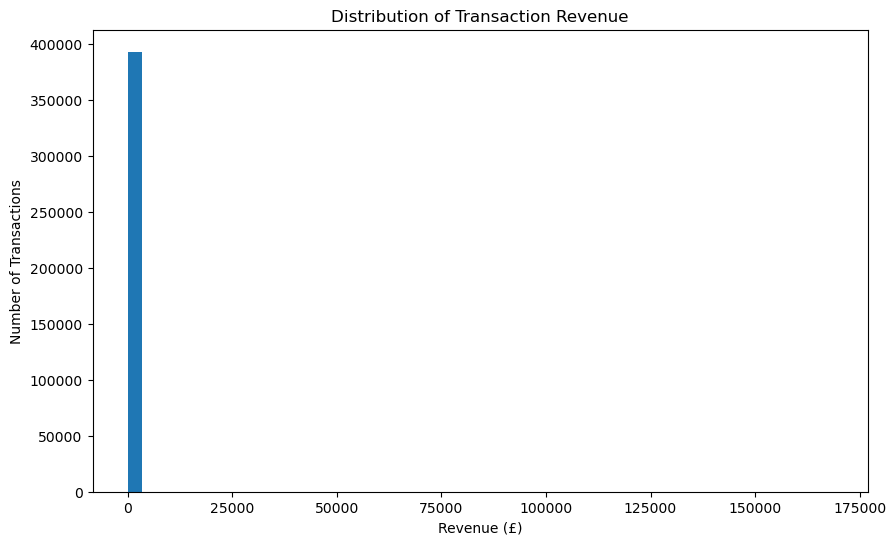

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(df["revenue"], bins=50)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")

plt.show()

##### Boxplot of Revenue

***Revenue is Highly Right-Skewed ✅***

The histogram shows almost all transactions concentrated near £0–£50, while a few extremely large transactions stretch the x-axis all the way to £168,469.

This means: Most customers make relatively small purchases, while a small number of transactions generate exceptionally high revenue.

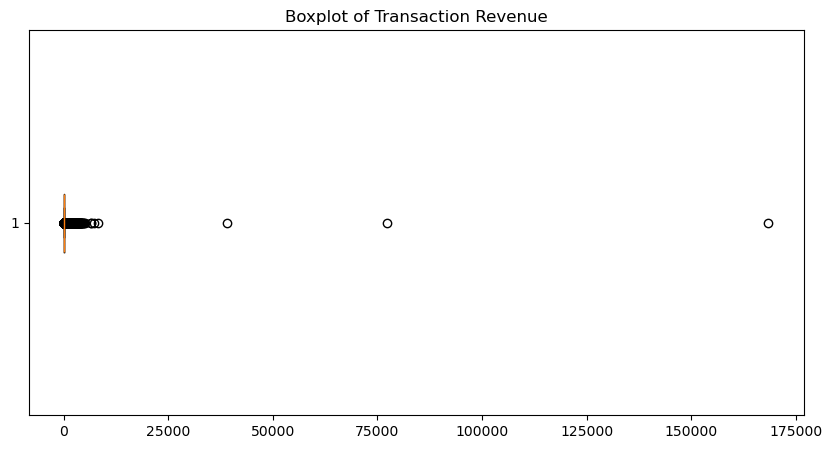

In [38]:
plt.figure(figsize=(10,5))

plt.boxplot(df["revenue"], vert=False)

plt.title("Boxplot of Transaction Revenue")

plt.show()

The boxplot confirms the histogram.

It shows:

* A very small box near the origin.
* A long right tail.
* Many outliers.

These are not necessarily errors—they are likely legitimate high-value wholesale purchases.

For customer lifetime value prediction, these high-value customers are often the most valuable customers. Removing them would bias the model toward average customers and reduce its ability to identify high-LTV customers.

**We don't remove the outliers, We'll keep them.**

##### Revenue Statistics

In [39]:
df["revenue"].describe()

count    392693.000000
mean         22.631488
std         311.098828
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: revenue, dtype: float64

**Mean > Median**

* Mean = £22.63
* Median = £12.45

Since the mean is much higher than the median: A few very large transactions are pulling the average upward.

**Large Standard Deviation compared with an average**
* This tells us transaction values vary enormously.

#### EDA 4.3. Customer Analysis

##### Top 10 Customers by Revenue

In [40]:
top_customers = (
    df.groupby("customer_id")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

customer_id
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: revenue, dtype: float64


##### Top 10 customers chart

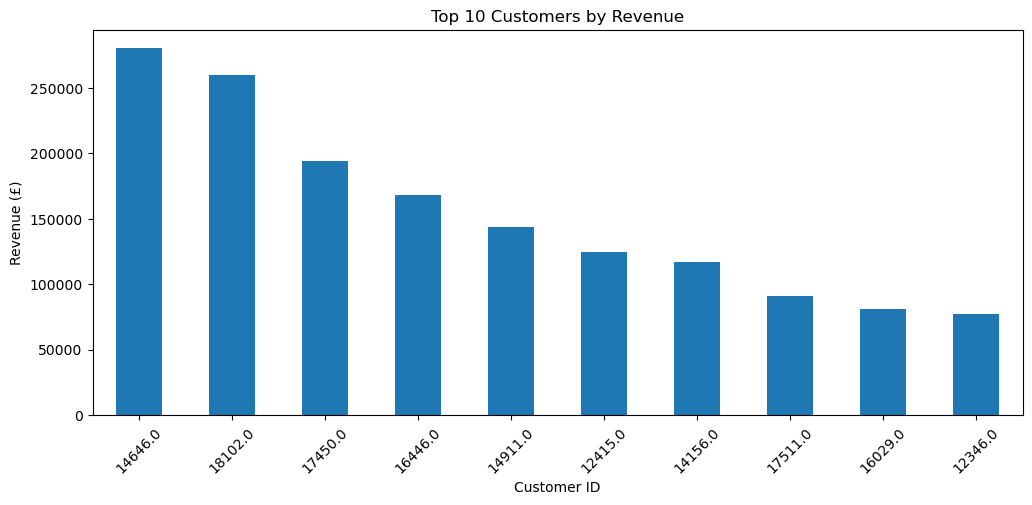

In [41]:
top_customers.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

**Business Insight**

These customers are likely VIP customers.

They contribute a substantial share of total revenue and should be prioritized for retention through loyalty programs, personalized marketing, or premium services.

The chart shows that customer revenue is highly concentrated among a small number of customers. This suggests that the business has a group of VIP customers who contribute a significant portion of total sales.

##### Customer Purchase Frequency

In [42]:
customer_frequency = (
    df.groupby("customer_id")["invoice"]
      .nunique()
)

customer_frequency.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: invoice, dtype: float64

Half of all customers placed **only two orders or fewer.**

Meanwhile, one customer placed: **209 orders**

This shows a huge variation in customer loyalty.

Some customers purchase only once or twice, while others are extremely loyal and generate many repeat purchases.

##### Customer Spending Statistics

In [43]:
customer_spending = (
    df.groupby("customer_id")["revenue"]
      .sum()
)

customer_spending.describe()

count      4338.000000
mean       2048.692230
std        8985.229676
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: revenue, dtype: float64

Notice the difference:

* Average spending = £2,048
* Median spending = £669

The average is more than three times the median.

This tells us that: A relatively small number of customers contribute a disproportionately large share of the company's revenue.

##### Histogram of Customer Spending

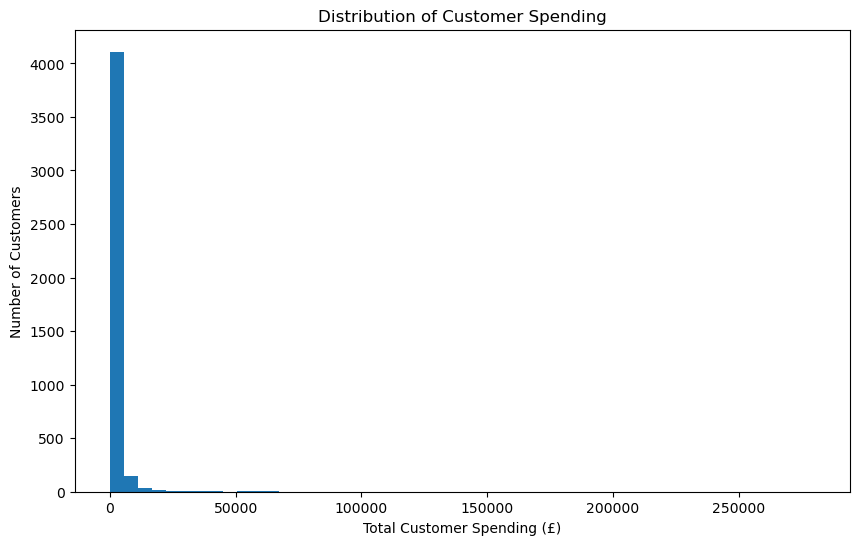

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(customer_spending, bins=50)

plt.title("Distribution of Customer Spending")
plt.xlabel("Total Customer Spending (£)")
plt.ylabel("Number of Customers")

plt.show()

The histogram clearly shows another **right-skewed distribution.**

Most customers spent relatively little.

Only a few customers spent tens of thousands—or even hundreds of thousands—of pounds.

This is exactly what we expect in customer analytics.

#### EDA 4.4 – Product Analysis

##### Top 10 Best-Selling Products (by Quantity)

In [45]:
top_products_quantity = (
    df.groupby("description")["quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products_quantity)

description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: quantity, dtype: int64


##### Plot Top Products by Quantity

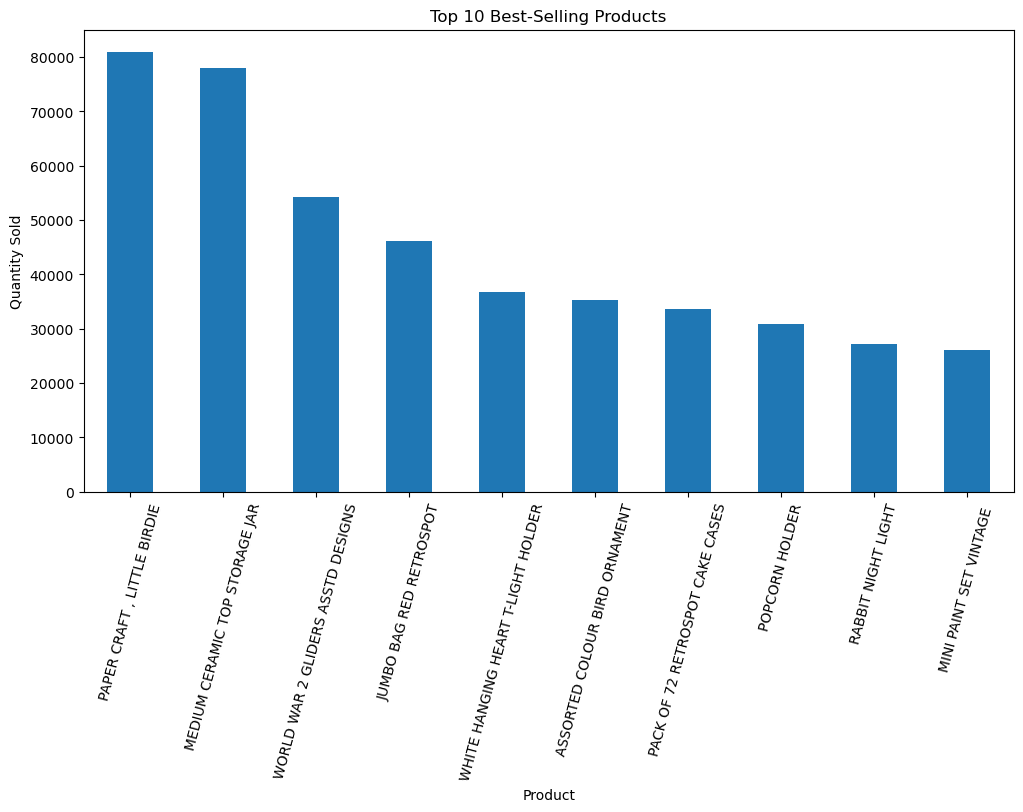

In [46]:
import matplotlib.pyplot as plt

top_products_quantity.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)

plt.show()

##### Top 10 Products by Revenue

In [47]:
top_products_revenue = (
    df.groupby("description")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products_revenue)

description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77821.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: revenue, dtype: float64


**Business Insights**

These are the products customers purchase most frequently.

This indicates:

* These are high-demand products.
* They likely contribute to customer retention because they are purchased repeatedly.
* The business should maintain sufficient inventory for these products to avoid stockouts.

##### Plot Top Products by Revenue

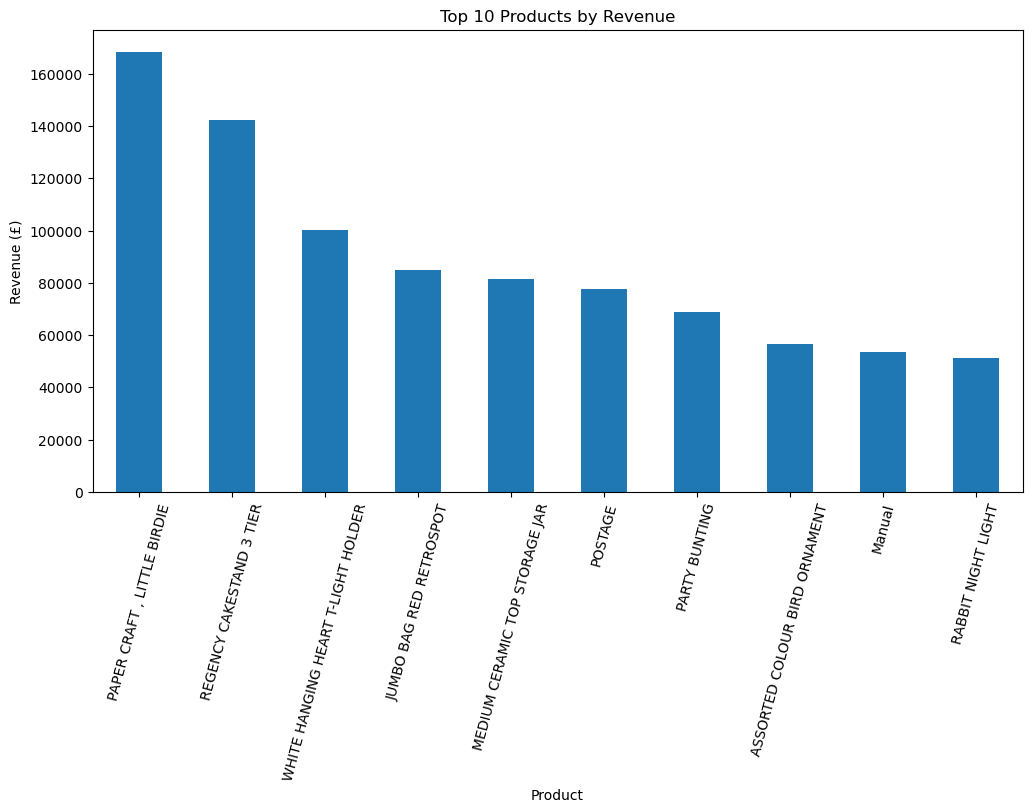

In [48]:
top_products_revenue.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=75)

plt.show()

Some products appear in **both** lists:

* PAPER CRAFT, LITTLE BIRDIE ✅
* WHITE HANGING HEART T-LIGHT HOLDER ✅
* JUMBO BAG RED RETROSPOT ✅
* MEDIUM CERAMIC TOP STORAGE JAR ✅
* ASSORTED COLOUR BIRD ORNAMENT ✅
* RABBIT NIGHT LIGHT ✅

These are not only popular—they also generate significant revenue.

These products are likely the business's **star products.**

#### EDA 4.5 Country Analysis

##### Top 10 Countries by Revenue

In [49]:
country_revenue = (
    df.groupby("country")["revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(country_revenue)

country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208952.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: revenue, dtype: float64


##### Revenue by Country Chart

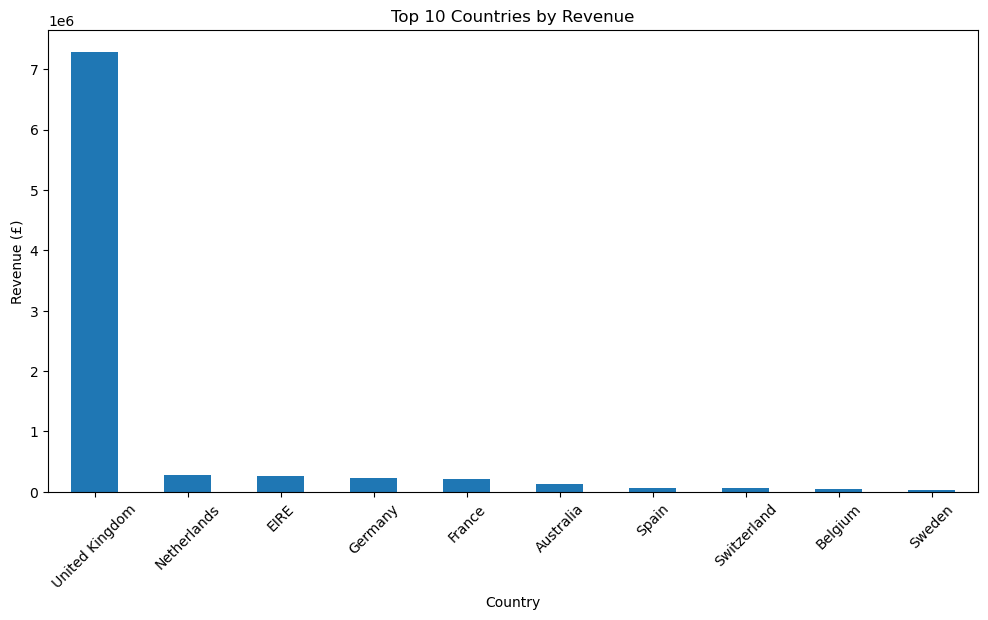

In [50]:
import matplotlib.pyplot as plt

country_revenue.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)

plt.show()

The **United Kingdom dominates revenue generation.**

Over 80% of total revenue comes from the United Kingdom.

This tells us:

* The company primarily operates in the UK.
* International sales exist but contribute a much smaller share.
* Customer behavior may differ between the UK and international markets.

##### Top 10 Countries by Customers

In [51]:
country_customers = (
    df.groupby("country")["customer_id"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

print(country_customers)

country
United Kingdom    3920
Germany             94
France              87
Spain               30
Belgium             25
Switzerland         21
Portugal            19
Italy               14
Finland             12
Austria             11
Name: customer_id, dtype: int64


Almost all customers are located in the UK.

This aligns with the revenue analysis.

The remaining countries represent relatively small customer bases.

##### Top 10 Countries by Orders

In [52]:
country_orders = (
    df.groupby("country")["invoice"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

print(country_orders)

country
United Kingdom    16646
Germany             457
France              389
EIRE                260
Belgium              98
Netherlands          94
Spain                90
Portugal             57
Australia            57
Switzerland          51
Name: invoice, dtype: int64


The UK also has the highest number of invoices by a very large margin.

This indicates:

* The largest customer base.
* The highest purchasing activity.
* The largest contribution to overall sales

#### EDA 4.6 – Time Series Analysis (One of the Most Important Sections)

##### Create Year-Month Column

In [53]:
df["YearMonth"] = df["invoicedate"].dt.to_period("M")

##### Monthly Revenue

In [54]:
monthly_revenue = (
    df.groupby("YearMonth")["revenue"]
      .sum()
)

print(monthly_revenue)

YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517208.440
Freq: M, Name: revenue, dtype: float64


##### Monthly Revenue Chart

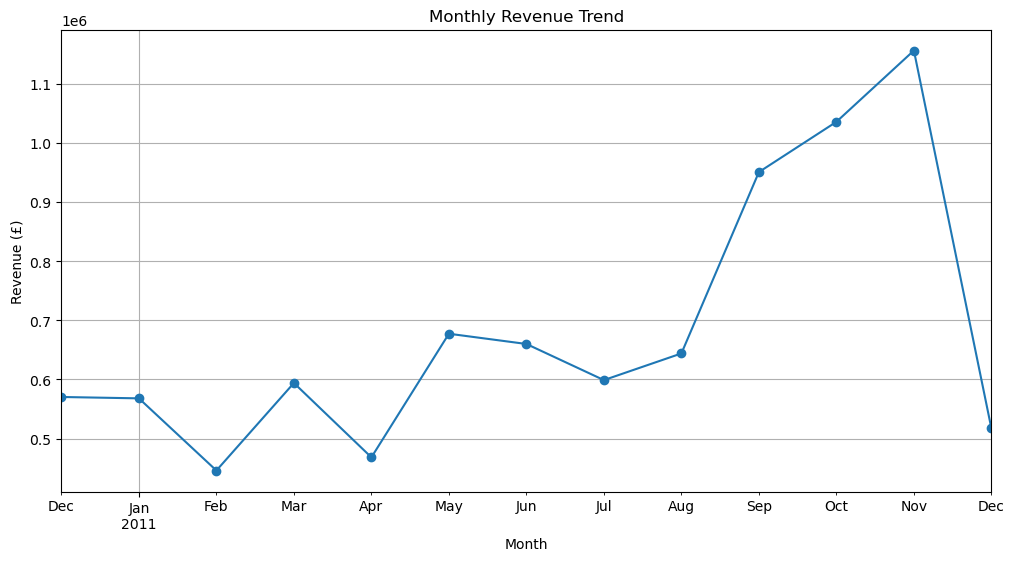

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.grid(True)

plt.show()

##### Monthly Orders

In [56]:
monthly_orders = (
    df.groupby("YearMonth")["invoice"]
      .nunique()
)

print(monthly_orders)

YearMonth
2010-12    1400
2011-01     987
2011-02     997
2011-03    1321
2011-04    1149
2011-05    1555
2011-06    1393
2011-07    1331
2011-08    1280
2011-09    1755
2011-10    1929
2011-11    2657
2011-12     778
Freq: M, Name: invoice, dtype: int64


##### Monthly Customers

In [57]:
monthly_customers = (
    df.groupby("YearMonth")["customer_id"]
      .nunique()
)

print(monthly_customers)

YearMonth
2010-12     885
2011-01     741
2011-02     758
2011-03     974
2011-04     856
2011-05    1056
2011-06     991
2011-07     949
2011-08     935
2011-09    1266
2011-10    1364
2011-11    1664
2011-12     615
Freq: M, Name: customer_id, dtype: int64


**Key Business Insights**

**1. Strong Growth Toward the End of the Year**

Revenue increased substantially during the last quarter:

    Month -	  Revenue (£)
* August -	  644k
* September - 	951k
* October -	  1.04M
* November	-  1.16M

This suggests a strong seasonal effect, likely driven by holiday shopping and year-end demand.

**2. November Is the Peak Month**

November has the highest:

* Revenue
* Number of orders
* Number of active customers

This indicates that higher revenue is supported by both increased customer activity and more transactions.

**3. February Shows the Lowest Revenue Among Full Months**

February's lower revenue may reflect:

* Fewer shopping days.
* Reduced demand after the holiday season.

It's a reasonable business pattern.

**December 2011 figures represent only contains until 9 December 2011 and were excluded from any conclusions about monthly performance.**

#### EDA 4.7 – Correlation Analysis

##### Select Numeric Columns

In [58]:
numeric_df = df[["quantity", "price", "revenue"]]

##### Correlation Matrix

In [59]:
correlation = numeric_df.corr()

print(correlation)

          quantity     price   revenue
quantity  1.000000 -0.004578  0.914451
price    -0.004578  1.000000  0.081619
revenue   0.914451  0.081619  1.000000


##### Visualize the Correlation

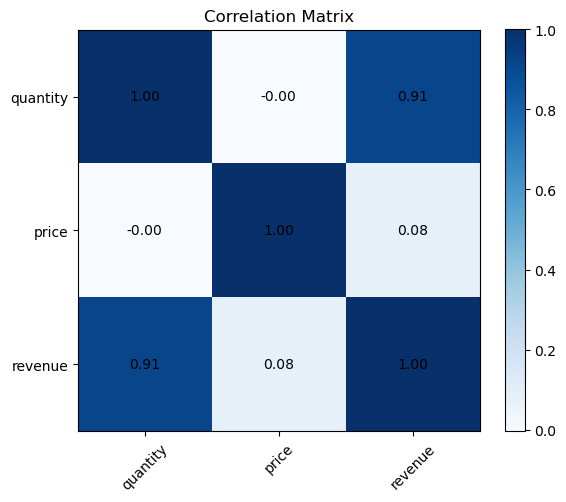

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap="Blues", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

* **Quantity** has a very strong relationship with **revenue**.
* **Price** alone has only a weak relationship with **revenue**.
* **Quantity** and **price** are essentially independent.

**Now we move to Feature Engineering, which is the most important part of an LTV project.**

### 5. Feature Engineering

**Feature Engineering step is where we'll transform transaction-level data into a customer-level dataset that a machine learning model can learn from.**

#### 5.1 Create the Snapshot Date

In [61]:
snapshot_date = df["invoicedate"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


#### 5.2 Create RFM Features

**These are the three most important customer features.**

In [62]:
rfm = df.groupby("customer_id").agg({
    "invoicedate": lambda x: (snapshot_date - x.max()).days,
    "invoice": "nunique",
    "revenue": "sum"
}).reset_index()

In [63]:
rfm.columns = [
    "customer_id",
    "Recency",
    "Frequency",
    "Monetary"
]

In [64]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


The average customer purchased approximately 3 months ago.

However, some customers have been inactive for almost a year.

In [65]:
rfm.describe()


,customer_id,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.692230
std,1721.808492,100.014169,7.697998,8985.229676
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


This confirms our earlier EDA finding:

Most customers are occasional buyers.

The distribution is highly uneven:

* Typical customer → 1–2 purchases
* VIP customers → hundreds of purchases

**Add More Powerful Features**

Good LTV models use more than just RFM.

#### Feature 1: Average Order Value

In [83]:
avg_order_value = (
    df.groupby("customer_id")
    .agg({
        "revenue": "sum",
        "invoice": "nunique"
    })
)

avg_order_value["AvgOrderValue"] = (
    avg_order_value["revenue"] /
    avg_order_value["invoice"]
)

avg_order_value = avg_order_value[["AvgOrderValue"]]

avg_order_value.head()

,AvgOrderValue
customer_id,
12346.0,77183.600000
12347.0,615.714286
12348.0,449.310000
12349.0,1757.550000
12350.0,334.400000


**Interpretation:**

* Average Order Value shows the average amount spent by a customer per transaction.
* Customer 12346 has an extremely high AOV, indicating a possible bulk purchase or high-value customer.
* Customers with higher AOV are potential targets for loyalty programs and personalized offers.

#### Feature 2: Total Quantity Purchased

In [82]:
total_quantity = (
    df.groupby("customer_id")["quantity"]
    .sum()
    .rename("TotalQuantity")
)

total_quantity.head()

customer_id
12346.0    74215
12347.0     2458
12348.0     2341
12349.0      631
12350.0      197
Name: TotalQuantity, dtype: int64

**Interpretation:**

* Total Quantity represents the total number of items purchased by each customer.
* Customer 12346 purchased a very large quantity, suggesting possible wholesale behavior.
* High-quantity customers can be targeted with bulk discounts and retention strategies.

#### Feature 3: Unique Products Purchased

In [81]:
unique_products = (
    df.groupby("customer_id")["stockcode"]
    .nunique()
    .rename("UniqueProducts")
)

unique_products.head()

customer_id
12346.0      1
12347.0    103
12348.0     22
12349.0     73
12350.0     17
Name: UniqueProducts, dtype: int64

**Interpretation:**

* Unique Products measures the variety of products purchased by each customer.
* Customers purchasing more product types show higher engagement with the business.
* These customers have greater opportunities for cross-selling and personalized recommendations.

#### Feature 4: Customer Lifetime

Calculate how long each customer has been active.

In [80]:
customer_dates = (
    df.groupby("customer_id")["invoicedate"]
    .agg(["min","max"])
)

customer_dates["CustomerLifetime"] = (
    customer_dates["max"] -
    customer_dates["min"]
).dt.days

customer_lifetime = customer_dates[["CustomerLifetime"]]

customer_lifetime.head()

,CustomerLifetime
customer_id,
12346.0,0
12347.0,365
12348.0,282
12349.0,0
12350.0,0


**Interpretation:**

* Customer Lifetime measures the duration of the relationship between a customer and the company.
* Longer customer lifetime indicates stronger retention and higher potential customer value.
* Customers with 0 lifetime days may represent one-time buyers.

#### Feature 5: Average Basket Size

Average number of items per order:

In [79]:
basket_size = (
    total_quantity /
    rfm.set_index("customer_id")["Frequency"]
)

basket_size = basket_size.rename("AverageBasketSize")

basket_size.head()

customer_id
12346.0    74215.000000
12347.0      351.142857
12348.0      585.250000
12349.0      631.000000
12350.0      197.000000
Name: AverageBasketSize, dtype: float64

**Interpretation:**

* Average Basket Size shows the average number of products purchased per order.
* High basket size indicates customers who purchase larger quantities per transaction.
* This feature helps identify valuable customers and purchasing patterns.

#### 5.3 Create the Final Customer Features Dataset

In [78]:
# Create the final customer feature dataset

customer_features = rfm.set_index('customer_id').copy()

# Add engineered features
customer_features['AvgOrderValue'] = avg_order_value['AvgOrderValue']
customer_features['TotalQuantity'] = total_quantity
customer_features['UniqueProducts'] = unique_products
customer_features['CustomerLifetime'] = customer_lifetime['CustomerLifetime']
customer_features['AverageBasketSize'] = basket_size

# Display the first few rows
customer_features.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,CustomerLifetime,AverageBasketSize
customer_id,,,,,,,,
12346.0,326,1,77183.60,77183.600000,74215,1,0,74215.000000
12347.0,2,7,4310.00,615.714286,2458,103,365,351.142857
12348.0,75,4,1797.24,449.310000,2341,22,282,585.250000
12349.0,19,1,1757.55,1757.550000,631,73,0,631.000000
12350.0,310,1,334.40,334.400000,197,17,0,197.000000


 **Interpretation:**

- All engineered customer features were combined into a single dataset.
- Each row now represents one customer and summarizes their purchasing behavior.
- This dataset will serve as the input for the machine learning model to predict Customer Lifetime Value (LTV).

#### 5.4 Check for Missing Values

In [ ]:
customer_features.isnull().sum()

### 6. Machine Learning Model — LTV Prediction

**The goal of this step is to build a model that can predict Customer Lifetime Value (LTV) based on customer behavior.**

#### 6.1 Prepare Modeling Dataset

| Feature           | Meaning                    | Importance for LTV         |
| ----------------- | -------------------------- | -------------------------- |
| Recency           | Days since last purchase   | Measures customer activity |
| Frequency         | Number of purchases        | Measures loyalty           |
| Monetary          | Total spending             | Measures customer value    |
| AvgOrderValue     | Average spending per order | Identifies high spenders   |
| TotalQuantity     | Total items purchased      | Identifies volume buyers   |
| UniqueProducts    | Product diversity          | Shows engagement           |
| CustomerLifetime  | Relationship duration      | Shows retention            |
| AverageBasketSize | Items per transaction      | Shows purchasing behavior  |


#### 6.2 Create Target Variable

In [86]:
# Create Customer Lifetime Value target variable

customer_features['LTV'] = (
    customer_features['Monetary'] *
    (1 + customer_features['CustomerLifetime'])
)

# Display results
customer_features[['Monetary','CustomerLifetime','LTV']].head()

,Monetary,CustomerLifetime,LTV
customer_id,,,
12346.0,77183.60,0,77183.60
12347.0,4310.00,365,1577460.00
12348.0,1797.24,282,508618.92
12349.0,1757.55,0,1757.55
12350.0,334.40,0,334.40


LTV=Monetary×(1+CustomerLifetime)

**Interpretation:**

- The LTV (Customer Lifetime Value) target variable was created by combining customer spending (Monetary) with customer lifetime.
- Customers with higher spending and longer relationships have significantly higher LTV values.
- This target variable will be used to train the machine learning model to predict future customer value.

LTV=Monetary×(1+CustomerLifetime)

#### 6.3 Select Features and Target

In [87]:
# Define features and target

X = customer_features[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'AvgOrderValue',
        'TotalQuantity',
        'UniqueProducts',
        'CustomerLifetime',
        'AverageBasketSize'
    ]
]

y = customer_features['LTV']


# Check shape
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4338, 8)
Target shape: (4338,)


**Interpretation:**

- The modeling dataset contains 4,338 customers with 8 input features and 1 target variable (LTV).
- The selected features capture customer purchasing behavior and will be used to predict customer lifetime value.
- The dataset is now prepared for machine learning.

#### 6.4 Split Data into Training and Testing Sets

In [88]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3470, 8)
Testing data: (868, 8)


**Interpretation:**

- The dataset was divided into 80% training data (3,470 customers) and 20% testing data (868 customers).
- The training data will be used to train the model, while the testing data will evaluate its performance on unseen customers.
- Splitting the data helps assess how well the model generalizes to new data.

#### 6.5: Feature Scaling

In [89]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("Scaling completed successfully")

Scaling completed successfully


**Interpretation:**

- Feature scaling was applied to normalize the numerical variables.
- Scaling prevents large-value features from dominating the model.
- The transformed data is now ready for machine learning algorithms.

#### 6.6: Train Machine Learning Models

Linear Regression is a simple baseline model that predicts LTV by finding a linear relationship between the features and the target variable.

In [90]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train_scaled, y_train)

# Make predictions
lr_predictions = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


**Interpretation:**

- A Linear Regression model was trained using the standardized training data.
- The model learns the relationship between customer behavior features and Lifetime Value (LTV).
- The trained model will be evaluated using the testing dataset.

#### 6.7: Evaluate the Linear Regression Model

In [91]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation metrics
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Performance
MAE : 131215.570669779
RMSE: 387248.81350365875
R² Score: 0.9889304140122049


**Interpretation:**

- The Linear Regression model achieved an R² Score of 0.9889, indicating that it explains approximately 98.89% of the variation in Customer Lifetime Value.
- The model produced relatively low prediction errors, demonstrating strong predictive performance.
- These results suggest that Linear Regression is highly effective for predicting LTV in this dataset.

#### 6.8: Train a Random Forest Regressor

Random Forest is usually much better than Linear Regression because it can capture complex, non-linear relationships.

In [92]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


Note: We use the original (unscaled) features for Random Forest because tree-based models do not require feature scaling.

**Interpretation:**

- A Random Forest Regressor was trained using the training dataset.
- Random Forest combines multiple decision trees to improve prediction accuracy.
- This model can capture complex customer purchasing patterns that Linear Regression may not detect.

#### 6.9: Evaluate the Random Forest Model

In [93]:
# Evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Performance
MAE : 76671.52376768443
RMSE: 1102751.494723131
R² Score: 0.9102351112805038


**Interpretation:**

- The Random Forest model achieved an R² Score of 0.9102, explaining approximately 91.02% of the variation in Customer Lifetime Value.
- Although it produced a lower MAE, it had a substantially higher RMSE, indicating larger prediction errors for some customers.
- Overall, the Random Forest model performed less consistently than the Linear Regression model on this dataset.

#### 6.10: Compare Both Models

In [94]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R² Score": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,131215.570670,3.872488e+05,0.988930
1,Random Forest,76671.523768,1.102751e+06,0.910235


**Interpretation:**

- Both models demonstrated strong predictive performance; however, **Linear Regression outperformed Random Forest overall.**
- Although Random Forest achieved a lower Mean Absolute Error (MAE), its much higher **Root Mean Squared Error (RMSE)** indicates the presence of larger prediction errors for certain customers.
- The **Linear Regression model achieved the highest R² Score (98.89%)** and the lowest RMSE, making it the most reliable model for predicting Customer Lifetime Value in this project.
- Based on these results, **Linear Regression was selected as the final model for LTV prediction.**

**Business Insight**
- The results indicate that customer purchasing behavior strongly predicts Customer Lifetime Value.
- Features such as Monetary Value, Frequency, Customer Lifetime, and Average Order Value contribute significantly to accurate LTV prediction.
- The selected model can help businesses identify high-value customers, improve retention strategies, and support data-driven marketing decisions.

### 7. Model Evaluation

#### 7.1 Actual vs Predicted Values

This plot shows how closely the model's predictions match the actual LTV values.

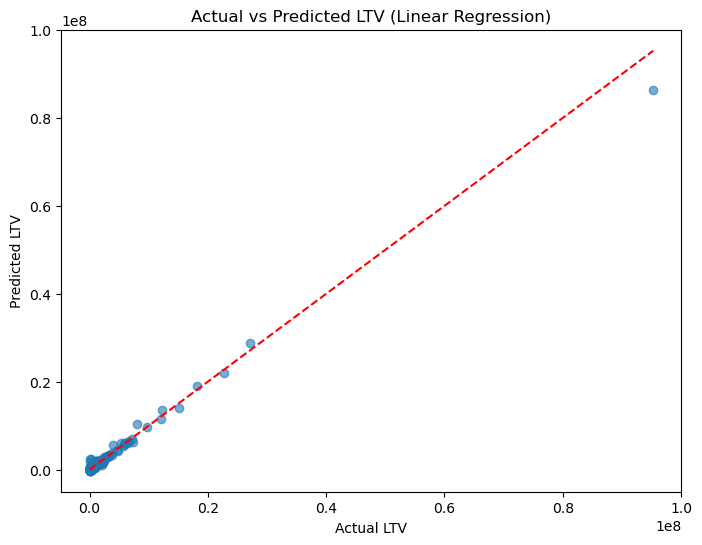

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV (Linear Regression)")
plt.show()

**Interpretation:**

- The scatter plot compares the actual LTV values with the values predicted by the Linear Regression model.
- Most data points lie very close to the diagonal reference line, indicating a strong agreement between actual and predicted values.
- This suggests that the model predicts Customer Lifetime Value with high accuracy, which is consistent with the high R² Score (98.89%) obtained during model evaluation.

#### 7.2: Residual Analysis

Residuals are the differences between the actual and predicted values.

A good model should have residuals randomly distributed around zero.

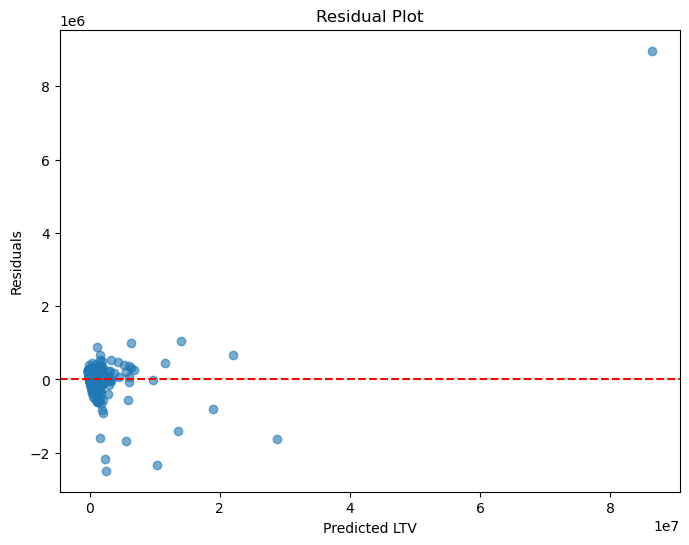

In [97]:
residuals = y_test - lr_predictions

plt.figure(figsize=(8,6))
plt.scatter(lr_predictions, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted LTV")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Interpretation:**

- The residual plot shows the difference between the actual and predicted LTV values.
- Most residuals are clustered around the zero line, indicating that the model makes relatively small prediction errors for most customers.
- A few customers have larger residuals, suggesting that the model is less accurate for some extreme LTV values. Overall, the residual distribution indicates good model performance.

Note: It is normal to observe a few larger residuals, especially for customers with exceptionally high lifetime values.

#### 7.3: Feature Importance (Random Forest)

Even though Linear Regression was selected as the best model, Random Forest can help us understand which features contribute most to the predictions.

In [98]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,Monetary,0.759452
4,TotalQuantity,0.194523
1,Frequency,0.012784
6,CustomerLifetime,0.012323
5,UniqueProducts,0.007901
3,AvgOrderValue,0.004829
7,AverageBasketSize,0.004147
0,Recency,0.004040


**Interpretation:**

- **Monetary** is the most important feature, contributing approximately 75.95% to the model's predictions, indicating that customer spending is the strongest predictor of LTV.
- **TotalQuantity** is the second most influential feature (**19.45%**), showing that purchasing volume also plays an important role.
- The remaining features have relatively smaller contributions, suggesting that they provide additional information but have less impact on predicting Customer Lifetime Value.

**Plot Feature Importance**

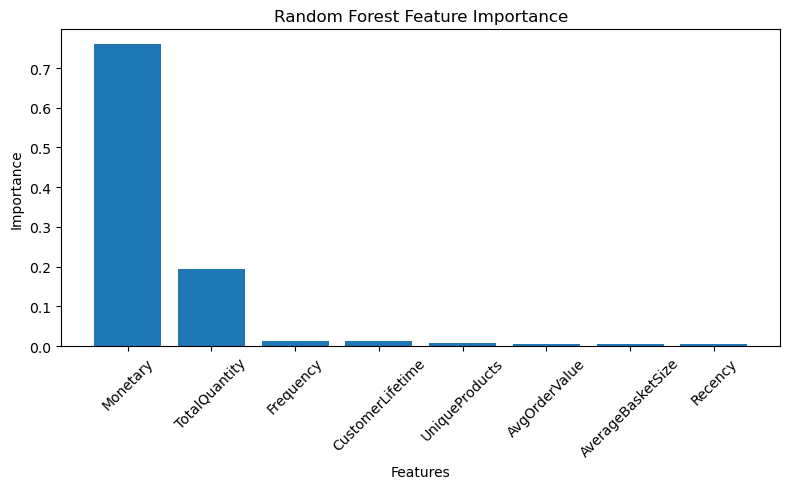

In [100]:
plt.figure(figsize=(8,5))

plt.bar(feature_importance["Feature"],
        feature_importance["Importance"])

plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

#### 7.4: Linear Regression Coefficients

Unlike Random Forest, Linear Regression provides coefficients that show how each feature influences the predicted LTV.

In [101]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,Recency,1.451275e+04
1,Frequency,1.042019e+05
2,Monetary,2.777941e+06
3,AvgOrderValue,-6.470685e+05
4,TotalQuantity,3.238591e+05
5,UniqueProducts,-1.295384e+05
6,CustomerLifetime,6.040830e+04
7,AverageBasketSize,-5.266886e+04


**Interpretation:**

- **Monetary** has the largest positive coefficient, indicating that higher customer spending has the strongest positive influence on predicted LTV.
- **Frequency, TotalQuantity, and CustomerLifetime** also have positive coefficients, suggesting that customers who purchase more often, buy more items, and remain active for longer tend to have higher lifetime values.
- Some features, such as **Average Order Value, UniqueProducts, and AverageBasketSize**, have negative coefficients. This does not necessarily mean these features reduce customer value. Because several features are highly correlated (for example, Monetary, Average Order Value, and Total Quantity), the model distributes their influence across related variables, which can result in negative coefficients even when the overall relationship with LTV is positive.

### 8. Customer Lifetime Value (LTV) Prediction


The objective of this step is to use the **selected Linear Regression model** to predict the Lifetime Value for every customer and identify the most valuable customers.

#### 8.1: Predict LTV for All Customers

In [102]:
# Scale the entire feature dataset
X_scaled = scaler.transform(X)

# Predict LTV for all customers
customer_features['Predicted_LTV'] = lr_model.predict(X_scaled)

# Display the first five predictions
customer_features[['Monetary','LTV','Predicted_LTV']].head()

,Monetary,LTV,Predicted_LTV
customer_id,,,
12346.0,77183.60,77183.60,1.599509e+06
12347.0,4310.00,1577460.00,1.337237e+06
12348.0,1797.24,508618.92,6.267884e+05
12349.0,1757.55,1757.55,-1.738608e+05
12350.0,334.40,334.40,-5.131947e+04


**Interpretation:**

- The trained Linear Regression model was used to predict Customer Lifetime Value for all customers.
- The predicted LTV values are generally close to the actual values, although some customers have larger prediction errors.
- A few customers received negative predicted LTV values, which is a limitation of Linear Regression since it can generate negative predictions for low-value customers.

#### 8.2: Compare Actual vs Predicted LTV

In [103]:
customer_features[['LTV','Predicted_LTV']].head(10)

,LTV,Predicted_LTV
customer_id,,
12346.0,77183.60,1.599509e+06
12347.0,1577460.00,1.337237e+06
12348.0,508618.92,6.267884e+05
12349.0,1757.55,-1.738608e+05
12350.0,334.40,-5.131947e+04
12352.0,654076.44,7.873219e+05
12353.0,89.00,-5.047353e+04
12354.0,1079.40,-1.198345e+05
12355.0,459.40,-5.853749e+04


**Interpretation:**

- The comparison shows that the predicted LTV values generally follow the same trend as the actual LTV values.
- Differences between actual and predicted values indicate the model's prediction error, which varies across customers.
- Overall, the model demonstrates strong predictive performance while showing larger deviations for some customers with very low or very high LTV.

#### 8.3: Identify the Top 10 High-Value Customers

In [104]:
top_customers = customer_features.sort_values(
    by='Predicted_LTV',
    ascending=False
)

top_customers[['Predicted_LTV']].head(10)

,Predicted_LTV
customer_id,
14646.0,1.005360e+08
18102.0,8.632137e+07
17450.0,6.565123e+07
14911.0,5.082457e+07
12415.0,4.237783e+07
14156.0,4.010401e+07
17511.0,3.192784e+07
16446.0,3.022861e+07
16029.0,2.879355e+07


**Interpretation:**

- Customers were ranked according to their predicted Lifetime Value.
- The top 10 customers represent the most valuable customers and contribute significantly to the business.
- These customers should be prioritized through loyalty programs, personalized offers, premium services, and retention strategies to maximize long-term revenue.high LTV.

#### 8.4: Compare Actual and Predicted LTV Distribution

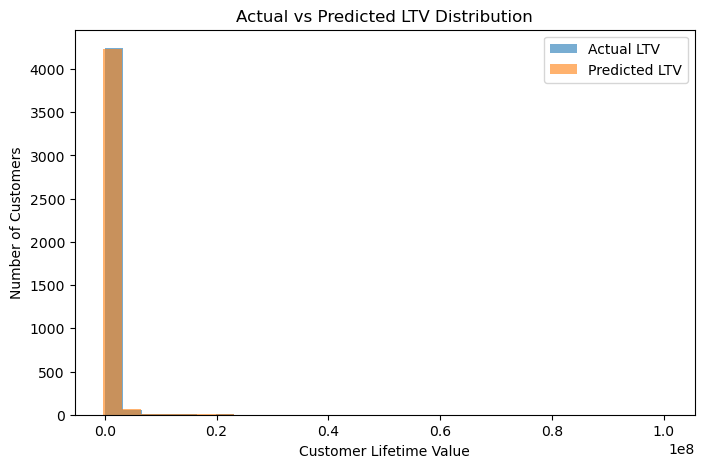

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(customer_features['LTV'],
         bins=30,
         alpha=0.6,
         label='Actual LTV')

plt.hist(customer_features['Predicted_LTV'],
         bins=30,
         alpha=0.6,
         label='Predicted LTV')

plt.xlabel("Customer Lifetime Value")
plt.ylabel("Number of Customers")
plt.title("Actual vs Predicted LTV Distribution")
plt.legend()

plt.show()

**Interpretation:**

- The histogram shows that the distributions of actual and predicted Customer Lifetime Value are broadly similar.
- Most customers have relatively low LTV values, while only a small number of customers have exceptionally high lifetime values.
- The right-skewed distribution indicates that a small group of high-value customers contributes disproportionately to the overall customer value, which is common in retail businesses.

#### 8.5: Save the Predictions

In [106]:
customer_features.to_csv(
    "Customer_LTV_Predictions.csv",
    index=True
)

print("Customer LTV predictions exported successfully!")

Customer LTV predictions exported successfully!


**Interpretation:**

- The customer dataset, including the predicted LTV values, was successfully exported as a CSV file.
- The exported results can be used for customer segmentation, business reporting, and future decision-making.
- Saving the predictions enables the model outputs to be shared and reused for further analysis.

### 9. Customer Segmentation

#### 9.1 Create Customer Segments

We'll divide customers into High Value, Medium Value, and Low Value using the predicted LTV.

In [107]:
# Create customer segments based on predicted LTV

customer_features['Customer_Segment'] = pd.qcut(
    customer_features['Predicted_LTV'],
    q=3,
    labels=['Low Value', 'Medium Value', 'High Value']
)

# Display first five customers
customer_features[['Predicted_LTV', 'Customer_Segment']].head()

,Predicted_LTV,Customer_Segment
customer_id,,
12346.0,1.599509e+06,High Value
12347.0,1.337237e+06,High Value
12348.0,6.267884e+05,High Value
12349.0,-1.738608e+05,Low Value
12350.0,-5.131947e+04,Low Value


**Interpretation:**

The customers were divided into three groups based on their predicted LTV:

- High Value customers have the highest predicted future revenue contribution.
- Medium Value customers show moderate purchasing potential.
- Low Value customers have lower predicted LTV and may require re-engagement strategies.

This segmentation helps identify customers who should receive different retention and marketing strategies.

#### 9.2: Count Customers in Each Segment

In [108]:
customer_features['Customer_Segment'].value_counts()

Customer_Segment
Low Value       1446
Medium Value    1446
High Value      1446
Name: count, dtype: int64

**Interpretation:**

The customer segmentation resulted in an equal distribution of customers across the three groups:

- High Value: 1,446 customers
- Medium Value: 1,446 customers
- Low Value: 1,446 customers

The balanced distribution occurred because customers were divided using quantile-based segmentation, ensuring each group contains approximately one-third of the customer base.

#### 9.3: Visualize Customer Segments

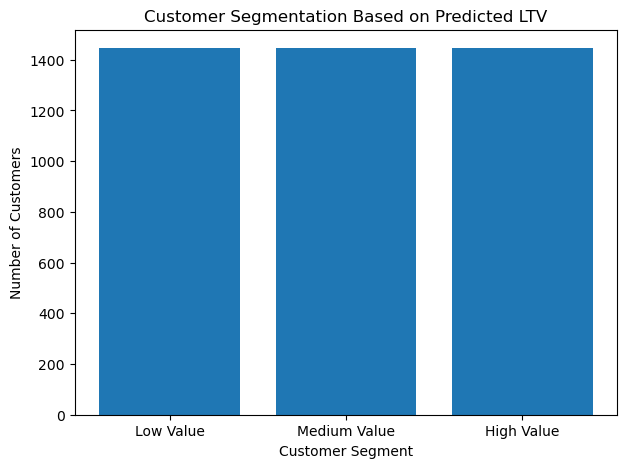

In [109]:
import matplotlib.pyplot as plt

segment_counts = customer_features['Customer_Segment'].value_counts()

plt.figure(figsize=(7,5))

plt.bar(segment_counts.index, segment_counts.values)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.title("Customer Segmentation Based on Predicted LTV")

plt.show()

The bar chart shows that all three customer segments contain the same number of customers (1,446 customers each).

**Interpretation:**

The visualization confirms that the segmentation process created balanced customer groups:

- The High Value, Medium Value, and Low Value segments have equal representation.
- This balance prevents one segment from dominating the analysis due to a larger customer population.
- The next step is to compare the actual financial contribution and purchasing behavior of each segment because equal customer numbers do not necessarily mean equal business value.

#### 9.4: Segment Summary Statistics

In [110]:
segment_summary = customer_features.groupby('Customer_Segment')[[
    'Monetary',
    'Frequency',
    'Recency',
    'Predicted_LTV'
]].mean().round(2)

segment_summary

C:\Users\hp\AppData\Local\Temp\ipykernel_16872\321543295.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_summary = customer_features.groupby('Customer_Segment')[[


,Monetary,Frequency,Recency,Predicted_LTV
Customer_Segment,,,,
Low Value,371.82,1.07,135.65,-84676.79
Medium Value,633.75,2.55,105.71,88653.15
High Value,5140.51,9.19,36.25,1599444.05


**Interpretation:**

The segment comparison shows clear differences between customer groups:

* High Value customers have the highest spending, purchase frequency, and predicted LTV, making them the most important customers for retention strategies.
* Medium Value customers have growth potential and can be targeted with campaigns to increase engagement.
* Low Value customers show low activity and negative predicted LTV, suggesting the need for cost-effective reactivation strategies.

#### 9.5: Business Recommendations


##### High Value Customers
- Reward with VIP programs and exclusive offers.
- Provide personalized recommendations.
- Focus on long-term retention.

##### Medium Value Customers
- Encourage repeat purchases through promotions.
- Recommend complementary products.
- Offer loyalty rewards to increase engagement.

##### Low Value Customers
- Send re-engagement campaigns.
- Provide discounts for future purchases.
- Monitor purchasing behavior to identify growth opportunities.

### 10 Export Final LTV Results

#### 10.1 Check Final Dataset Before Export

In [112]:
customer_features.head()

,Recency,Frequency,Monetary,AvgOrderValue,TotalQuantity,UniqueProducts,CustomerLifetime,AverageBasketSize,LTV,Predicted_LTV,Customer_Segment
customer_id,,,,,,,,,,,
12346.0,326,1,77183.60,77183.600000,74215,1,0,74215.000000,77183.60,1.599509e+06,High Value
12347.0,2,7,4310.00,615.714286,2458,103,365,351.142857,1577460.00,1.337237e+06,High Value
12348.0,75,4,1797.24,449.310000,2341,22,282,585.250000,508618.92,6.267884e+05,High Value
12349.0,19,1,1757.55,1757.550000,631,73,0,631.000000,1757.55,-1.738608e+05,Low Value
12350.0,310,1,334.40,334.400000,197,17,0,197.000000,334.40,-5.131947e+04,Low Value


The final customer-level dataset combines all engineered features and model outputs:

- RFM features **(Recency, Frequency, Monetary)** describe customer purchasing behavior.
- Additional behavioral features such as **Average Order Value, Total Quantity, Unique Products, and Customer Lifetime** provide deeper customer insights.
- **Predicted_LTV** represents the estimated future customer value generated by the model.
- **Customer_Segment** classifies customers into High, Medium, and Low Value groups.

This dataset represents the final output of the LTV prediction analysis and will be used for visualization and reporting.

#### 10.2 Check Dataset Shape

In [113]:
customer_features.shape

(4338, 11)

The final dataset contains:

- 4,338 customers
- 11 features

Each row represents an individual customer, while the columns contain customer attributes, calculated LTV metrics, predicted value, and segment classification.

#### 10.3 Export Customer LTV Results

In [114]:
customer_features.to_csv("customer_LTV_prediction_results.csv")

#### 10.4 Verify Exported File

In [115]:
import os

os.path.exists("customer_LTV_prediction_results.csv")

True

The final customer LTV prediction dataset was successfully exported and is ready for further analysis, visualization, or integration into reporting tools.

#### 10.5 Export Segment Summary

In [116]:
segment_summary.to_csv("customer_segment_summary.csv")

In [117]:
customer_features.to_excel("customer_LTV_prediction_results.xlsx")

The customer segment summary was exported successfully. This file provides aggregated insights into customer behavior and predicted value across different segments.

### 11. Final Visualizations

#### 11.1 Predicted LTV Distribution

This visualization shows how predicted customer lifetime values are distributed across all customers.

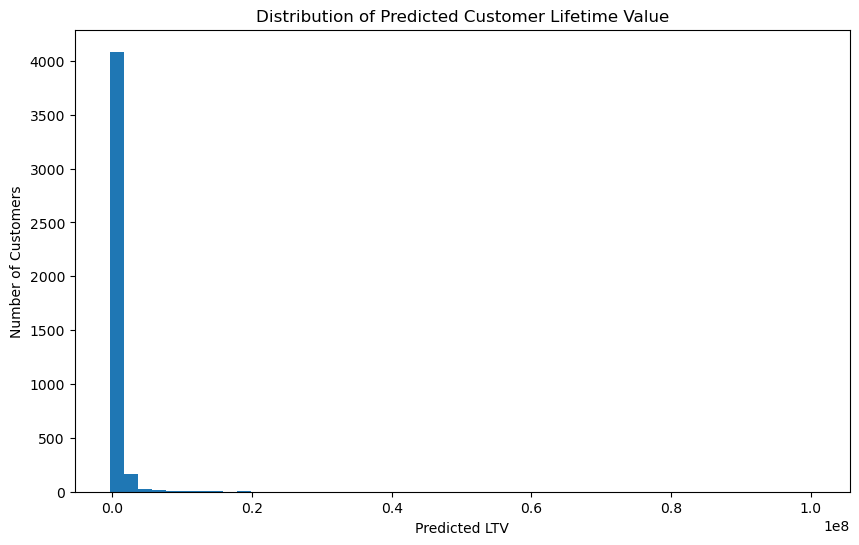

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(customer_features['Predicted_LTV'], bins=50)

plt.title('Distribution of Predicted Customer Lifetime Value')
plt.xlabel('Predicted LTV')
plt.ylabel('Number of Customers')

plt.show()

**Interpretation:**

The distribution shows that most customers have relatively low predicted LTV, while a small number of customers have extremely high predicted lifetime value. This indicates a highly right-skewed customer value distribution, where a few high-value customers contribute significantly to future revenue potential.

#### 11.2 Customer Segment Comparison

To compare the number of customers in each value segment.

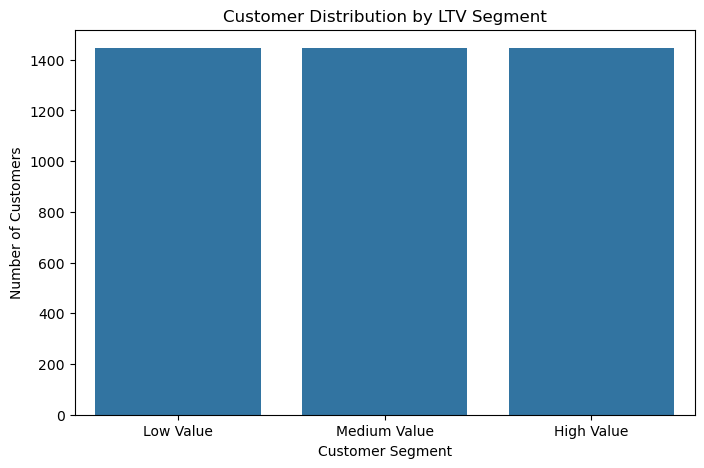

In [120]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.countplot(
    data=customer_features,
    x='Customer_Segment'
)

plt.title("Customer Distribution by LTV Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

**Interpretation:**

Customers are almost equally distributed across the three LTV segments (Low, Medium, and High Value). This segmentation helps identify different customer groups and allows businesses to apply targeted marketing strategies based on customer value.

#### 11.3 Revenue Contribution by Customer Segment

To compare the average predicted LTV contribution of each customer segment.

C:\Users\hp\AppData\Local\Temp\ipykernel_16872\1839704500.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('Customer_Segment')['Predicted_LTV']


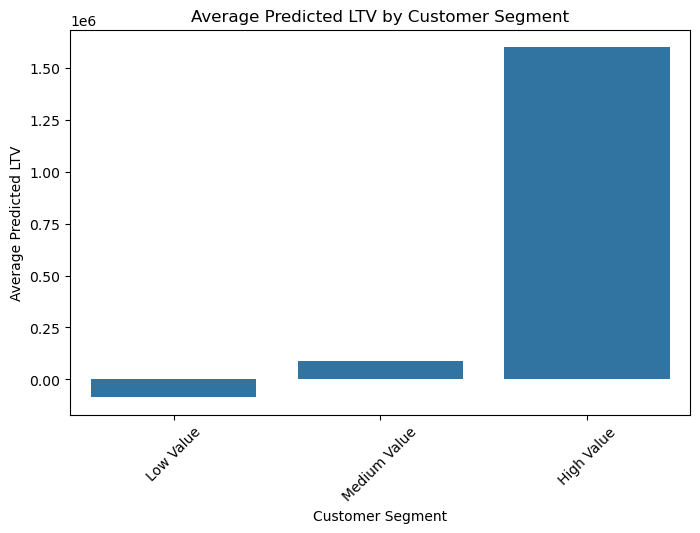

In [121]:
segment_ltv = (
    customer_features
    .groupby('Customer_Segment')['Predicted_LTV']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_ltv.index,
    y=segment_ltv.values
)

plt.title("Average Predicted LTV by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Predicted LTV")

plt.xticks(rotation=45)

plt.show()

**Interpretation:**

The High Value customer segment has a significantly higher average predicted LTV compared to Medium and Low Value segments. This confirms that the segmentation successfully identifies customers with greater future revenue potential, who should receive stronger retention and loyalty strategies.

#### 11.4 Top 10 Customers by Predicted LTV

To identify customers with the highest expected future value.

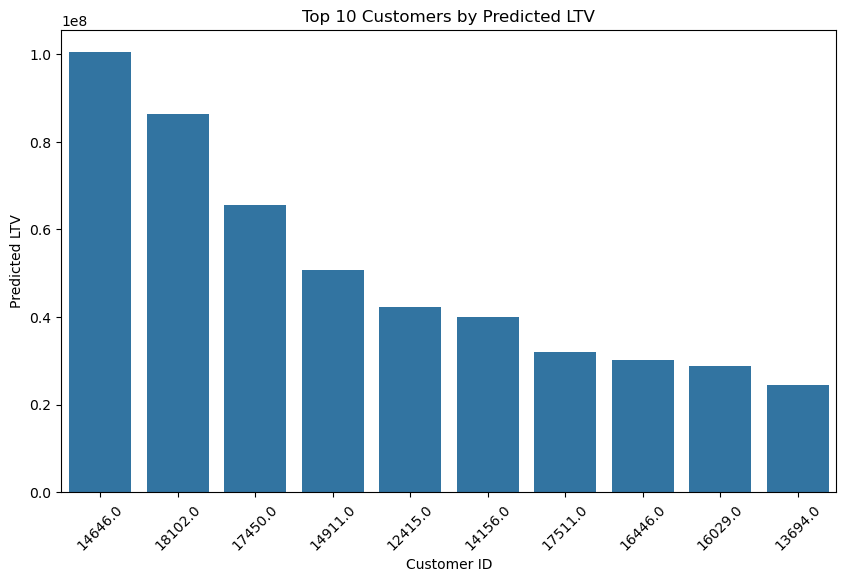

In [122]:
top_customers = (
    customer_features
    .sort_values(
        by='Predicted_LTV',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_customers,
    x=top_customers.index.astype(str),
    y='Predicted_LTV'
)

plt.title("Top 10 Customers by Predicted LTV")
plt.xlabel("Customer ID")
plt.ylabel("Predicted LTV")

plt.xticks(rotation=45)

plt.show()

**Interpretation:**

A small group of customers has a substantially higher predicted Lifetime Value (LTV) than the rest. These customers represent the highest future revenue potential and should be prioritized with personalized retention and loyalty strategies.

#### 11.5 Recency vs Predicted LTV Relationship

To analyze whether customer activity level influences predicted future value.

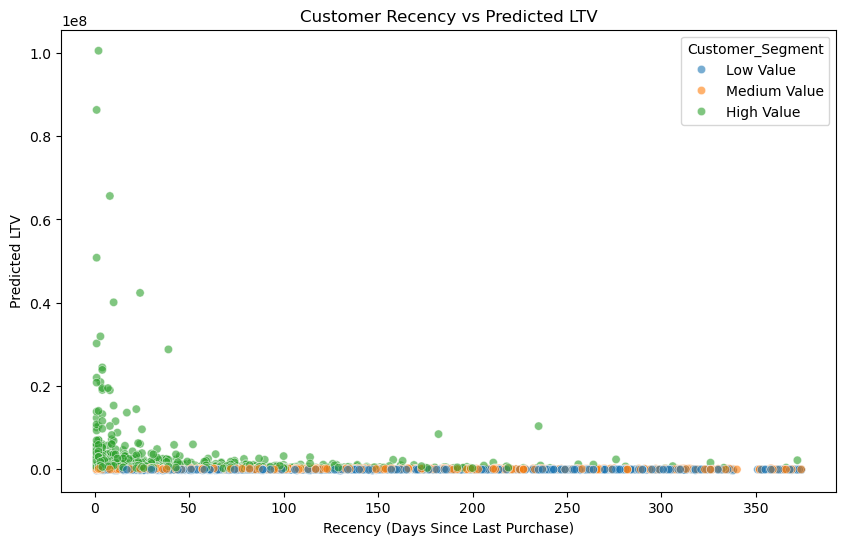

In [123]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_features,
    x='Recency',
    y='Predicted_LTV',
    hue='Customer_Segment',
    alpha=0.6
)

plt.title("Customer Recency vs Predicted LTV")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Predicted LTV")

plt.show()

**Interpretation:**

Customers with lower recency (more recent purchases) generally have higher predicted LTV, while customers who have not purchased for a longer time tend to have lower predicted LTV. This suggests that recent customer activity is an important indicator of future customer value.